In [22]:
import pandas as pd
import pathlib
import rootutils
import torch
import tqdm
import numpy as np
import seaborn as sns
import colorcet as cc
import sklearn

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

from torch.nn import functional as F
from matplotlib import pyplot as plt

from src.core.data.soundscape_embeddings import SoundscapeEmbeddingsDataModule
from src.core.models.mil_species_detector import MILSpeciesDetector
from src.core.models.sivae import SIVAE

scope = "SO_UK"
model_name = "wanted-pencil"

vae = SIVAE.load_from_checkpoint(f"/its/home/kag25/models/v3/sivae/{model_name}/step=180000.ckpt")
clf = MILSpeciesDetector.load_from_checkpoint(f"/its/home/kag25/models/v3/bayesian_species_detectors/{model_name}_{scope}.ckpt")
features = pd.read_parquet(f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/{scope}/val/features.parquet").reset_index()
labels = pd.read_parquet(f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/{scope}/val/labels.parquet").reset_index()
scores = pd.read_parquet(f"/its/home/kag25/experiments/v3/bayesian_species_detectors/scores/val_scores.parquet")
preds = pd.read_parquet(f"/its/home/kag25/experiments/v3/bayesian_species_detectors/predictions/val.parquet/{model_name}-{scope}.parquet").reset_index()

scores = scores[scores.model == model_name]
scores = scores.iloc[scores["AP"].argsort()[::-1]]
order = scores.species_name.unique()
scores

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

,species_name,AP,auROC,train_label_counts,run_id,model,scope,seed,attention,classifiers,clf_regulariser,attn_regulariser,beta,gamma_clf,gamma_attn,label_smoothing,clf_learning_rate,attn_learning_rate,epoch
107,Turdus merula_Eurasian Blackbird,0.899958,0.919982,588,gleaming-message,wanted-pencil,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005,700
127,Erithacus rubecula_European Robin,0.888972,0.887056,578,gleaming-message,wanted-pencil,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005,700
118,Troglodytes hiemalis_Winter Wren,0.804128,0.854402,556,gleaming-message,wanted-pencil,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005,700
117,Phylloscopus collybita_Common Chiffchaff,0.760695,0.854822,351,gleaming-message,wanted-pencil,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005,700
91,Turdus philomelos_Song Thrush,0.736540,0.868660,426,gleaming-message,wanted-pencil,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005,700
131,Columba palumbus_Common Wood-Pigeon,0.685140,0.827297,432,gleaming-message,wanted-pencil,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005,700
116,Alauda arvensis_Eurasian Skylark,0.624845,0.867869,192,gleaming-message,wanted-pencil,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005,700
130,Phasianus colchicus_Ring-necked Pheasant,0.527282,0.740972,324,gleaming-message,wanted-pencil,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005,700
122,Corvus corone_Carrion Crow,0.452866,0.792728,140,gleaming-message,wanted-pencil,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005,700
95,Emberiza citrinella_Yellowhammer,0.439854,0.896054,96,gleaming-message,wanted-pencil,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.0005,700


In [3]:
features.head()

,file_i,dataloader_idx,timestep,z_mean_0,z_mean_1,z_mean_2,z_mean_3,z_mean_4,z_mean_5,z_mean_6,...,z_log_var_118,z_log_var_119,z_log_var_120,z_log_var_121,z_log_var_122,z_log_var_123,z_log_var_124,z_log_var_125,z_log_var_126,z_log_var_127
0,0,1,0,-1.789027,1.932905,-0.803497,-2.254097,1.521769,1.274189,-1.160168,...,-10.408632,-7.056836,-10.452461,-9.644507,-8.738744,-7.607335,-12.250543,-23.02585,-9.331558,-8.144196
1,0,1,1,-0.399227,-0.405813,2.004248,-2.167991,2.368318,1.254966,-1.793983,...,-10.452145,-9.357033,-8.835960,-10.223238,-7.890681,-8.066425,-12.305705,-23.02585,-9.338136,-8.605151
2,0,1,2,1.658857,0.303998,1.114585,-1.059845,1.899312,-0.404597,-0.673271,...,-8.640041,-7.527762,-9.177353,-9.257811,-9.066619,-6.877771,-11.157537,-23.02585,-8.860314,-7.748199
3,0,1,3,1.341059,-2.317770,0.938916,-3.589662,2.933789,3.769215,-5.537024,...,-10.305490,-9.063707,-11.224001,-11.274333,-8.923385,-9.568980,-13.123131,-23.02585,-10.335163,-8.691960
4,0,1,4,1.226442,-0.191686,-0.277106,-1.261382,-1.502937,1.423206,1.072975,...,-10.192638,-10.388783,-10.593149,-12.209767,-11.188864,-9.583952,-14.906672,-23.02585,-11.348188,-9.418499


In [4]:
labels.head()

,file_i,Acrocephalus scirpaceus_Eurasian Reed Warbler,Aegithalos caudatus_Long-tailed Tit,Alauda arvensis_Eurasian Skylark,Alectoris rufa_Red-legged Partridge,Anthus pratensis_Meadow Pipit,Ardea cinerea_Gray Heron,Aythya collaris_Ring-necked Duck,Branta canadensis_Canada Goose,Buteo buteo_Common Buzzard,...,Sturnus vulgaris_European Starling,Sylvia atricapilla_Eurasian Blackcap,Sylvia borin_Garden Warbler,Troglodytes hiemalis_Winter Wren,Turdus merula_Eurasian Blackbird,Turdus philomelos_Song Thrush,Turdus viscivorus_Mistle Thrush,Tyto alba_Barn Owl,Vanellus gregarius_Sociable Plover,Vanellus vanellus_Northern Lapwing
0,0,0,0,0,0,0,0,0,0,1,...,0,1,0,1,1,1,0,0,0,0
1,9,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,13,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,30,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,1,0,0,0,0
4,31,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
preds.head()

,dataloader_idx,file_i,sample_i,t,species_i,y_t_prob,mu_a,sigma_sq_a,attn_w
0,1,0,0,0,0,0.774491,1.245958,0.050244,0.004172
1,1,0,0,0,1,0.000370,-8.109275,0.135074,0.002658
2,1,0,0,0,2,0.009847,-4.758151,0.165477,0.016768
3,1,0,0,0,3,0.000600,-7.593290,0.121661,0.006484
4,1,0,0,0,4,0.000022,-10.983370,0.118687,0.004064


---

# Global Uncertainty by Species

In [59]:
species = "Turdus merula_Eurasian Blackbird"
species_labels = labels.loc[:, ["file_i", species]]
present_species_idx = species_labels[species_labels[species] == 1].file_i
species_features = features.loc[features.file_i.isin(present_species_idx), ["file_i", "timestep", *[f"z_log_var_{i}" for i in range(128)]]].copy()
species_features

,file_i,timestep,z_log_var_0,z_log_var_1,z_log_var_2,z_log_var_3,z_log_var_4,z_log_var_5,z_log_var_6,z_log_var_7,...,z_log_var_118,z_log_var_119,z_log_var_120,z_log_var_121,z_log_var_122,z_log_var_123,z_log_var_124,z_log_var_125,z_log_var_126,z_log_var_127
0,0,0,-7.482964,-9.671599,-23.025850,-11.690803,-7.517198,-8.714487,-10.027800,-9.012959,...,-10.408632,-7.056836,-10.452461,-9.644507,-8.738744,-7.607335,-12.250543,-23.02585,-9.331558,-8.144196
1,0,1,-8.917847,-10.407978,-23.025850,-10.941456,-6.891989,-7.903147,-7.003040,-8.572636,...,-10.452145,-9.357033,-8.835960,-10.223238,-7.890681,-8.066425,-12.305705,-23.02585,-9.338136,-8.605151
2,0,2,-8.335135,-8.534494,-21.149090,-8.360739,-7.345600,-9.417929,-8.670115,-8.323519,...,-8.640041,-7.527762,-9.177353,-9.257811,-9.066619,-6.877771,-11.157537,-23.02585,-8.860314,-7.748199
3,0,3,-8.439379,-10.102272,-23.025850,-11.064902,-8.091642,-9.287388,-9.253326,-9.623712,...,-10.305490,-9.063707,-11.224001,-11.274333,-8.923385,-9.568980,-13.123131,-23.02585,-10.335163,-8.691960
4,0,4,-9.907967,-10.814530,-23.025850,-11.182211,-8.227360,-10.291088,-10.886271,-9.514607,...,-10.192638,-10.388783,-10.593149,-12.209767,-11.188864,-9.583952,-14.906672,-23.02585,-11.348188,-9.418499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24943,2021,72,-9.439574,-11.407627,-23.025850,-9.653707,-8.942176,-9.457975,-9.027460,-10.409529,...,-12.012349,-7.249002,-8.983492,-9.914581,-9.238837,-7.425000,-11.488126,-23.02585,-9.253815,-8.654369
24944,2021,73,-7.899196,-10.345736,-21.973804,-8.734792,-7.462354,-8.583176,-7.151447,-8.888576,...,-10.296682,-8.127971,-7.778718,-9.930250,-7.932557,-8.081394,-11.037136,-23.02585,-9.792032,-8.107889
24945,2021,74,-9.064638,-12.587112,-23.025850,-10.117112,-8.804616,-9.027328,-8.599029,-10.354976,...,-12.432846,-9.267323,-10.666018,-11.542484,-9.102185,-9.204405,-11.421835,-23.02585,-9.964918,-8.941490
24946,2021,75,-8.939544,-10.953253,-23.025850,-9.655109,-8.814114,-9.273544,-8.857813,-9.310134,...,-10.920422,-8.440857,-9.819016,-10.290697,-8.946722,-10.229470,-12.152598,-23.02585,-10.509602,-9.183485


In [61]:
z_long = species_features.melt(id_vars=["file_i", "timestep"], var_name="var", value_name="z_log_var")
z_long["var_index"] = z_long["var"].str.extract(r"(\d+)").astype(int)
z_long = z_long.drop("var", axis=1)
z_long["z_var"] = np.exp(z_long["z_log_var"])
z_long

,file_i,timestep,z_log_var,var_index,z_var
0,0,0,-7.482964,0,0.000563
1,0,1,-8.917847,0,0.000134
2,0,2,-8.335135,0,0.000240
3,0,3,-8.439379,0,0.000216
4,0,4,-9.907967,0,0.000050
...,...,...,...,...,...
1448827,2021,72,-8.654369,127,0.000174
1448828,2021,73,-8.107889,127,0.000301
1448829,2021,74,-8.941490,127,0.000131
1448830,2021,75,-9.183485,127,0.000103


In [7]:
w_log_var = clf.classifiers.weight_log_var[clf.target_names.index(species)].detach().numpy()
w_long = pd.DataFrame(data=[w_log_var], columns=[f"w_log_var_{i}" for i in range(128)]).melt(value_name="w_log_var").drop("variable", axis=1).reset_index(names="var_index")
w_long["w_var"] = np.exp(w_long["w_log_var"])
w_long

,var_index,w_log_var,w_var
0,0,-10.140875,0.000039
1,1,-9.976055,0.000047
2,2,-9.641655,0.000065
3,3,-9.994965,0.000046
4,4,-9.851802,0.000053
...,...,...,...
123,123,-9.891651,0.000051
124,124,-10.112960,0.000041
125,125,-9.725327,0.000060
126,126,-10.119126,0.000040


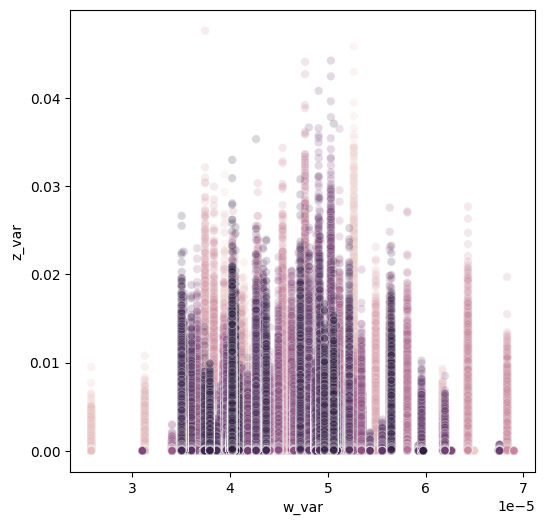

In [12]:
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=z_long.merge(w_long, on="var_index", how="left"),
    x="w_var", y="z_var",
    hue="var_index",
    alpha=0.2,
    legend=False
)
plt.show()

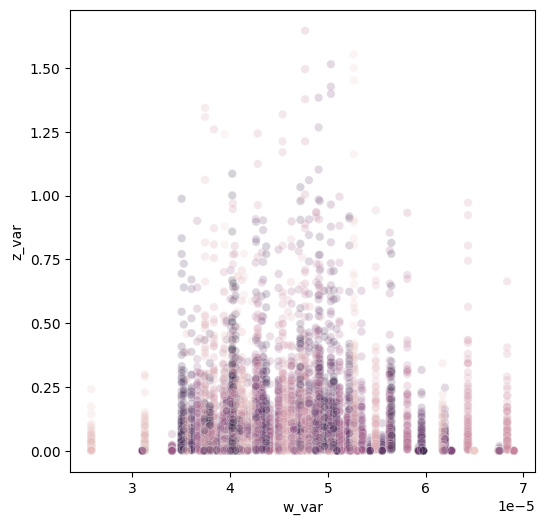

In [11]:
z_long_grouped = z_long.groupby(["file_i", "var_index"])["z_var"].sum().reset_index()
z_long_grouped["z_log_var"] = np.log(z_long_grouped["z_var"])
plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=z_long_grouped.merge(w_long, on=["var_index"], how="left"),
    x="w_var", y="z_var",
    hue="var_index",
    alpha=0.2,
    legend=False
)
plt.show()

---

# Instance Level Uncertainty

In [28]:
species = "Turdus merula_Eurasian Blackbird"
species_labels = labels.loc[:, ["file_i", species]]
present_species_idx = species_labels[species_labels[species] == 1].file_i
species_features = features.loc[features.file_i.isin(present_species_idx), ["file_i", "timestep", *[f"z_log_var_{i}" for i in range(128)]]].copy()
species_features

,file_i,timestep,z_log_var_0,z_log_var_1,z_log_var_2,z_log_var_3,z_log_var_4,z_log_var_5,z_log_var_6,z_log_var_7,...,z_log_var_118,z_log_var_119,z_log_var_120,z_log_var_121,z_log_var_122,z_log_var_123,z_log_var_124,z_log_var_125,z_log_var_126,z_log_var_127
0,0,0,-7.482964,-9.671599,-23.025850,-11.690803,-7.517198,-8.714487,-10.027800,-9.012959,...,-10.408632,-7.056836,-10.452461,-9.644507,-8.738744,-7.607335,-12.250543,-23.02585,-9.331558,-8.144196
1,0,1,-8.917847,-10.407978,-23.025850,-10.941456,-6.891989,-7.903147,-7.003040,-8.572636,...,-10.452145,-9.357033,-8.835960,-10.223238,-7.890681,-8.066425,-12.305705,-23.02585,-9.338136,-8.605151
2,0,2,-8.335135,-8.534494,-21.149090,-8.360739,-7.345600,-9.417929,-8.670115,-8.323519,...,-8.640041,-7.527762,-9.177353,-9.257811,-9.066619,-6.877771,-11.157537,-23.02585,-8.860314,-7.748199
3,0,3,-8.439379,-10.102272,-23.025850,-11.064902,-8.091642,-9.287388,-9.253326,-9.623712,...,-10.305490,-9.063707,-11.224001,-11.274333,-8.923385,-9.568980,-13.123131,-23.02585,-10.335163,-8.691960
4,0,4,-9.907967,-10.814530,-23.025850,-11.182211,-8.227360,-10.291088,-10.886271,-9.514607,...,-10.192638,-10.388783,-10.593149,-12.209767,-11.188864,-9.583952,-14.906672,-23.02585,-11.348188,-9.418499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24943,2021,72,-9.439574,-11.407627,-23.025850,-9.653707,-8.942176,-9.457975,-9.027460,-10.409529,...,-12.012349,-7.249002,-8.983492,-9.914581,-9.238837,-7.425000,-11.488126,-23.02585,-9.253815,-8.654369
24944,2021,73,-7.899196,-10.345736,-21.973804,-8.734792,-7.462354,-8.583176,-7.151447,-8.888576,...,-10.296682,-8.127971,-7.778718,-9.930250,-7.932557,-8.081394,-11.037136,-23.02585,-9.792032,-8.107889
24945,2021,74,-9.064638,-12.587112,-23.025850,-10.117112,-8.804616,-9.027328,-8.599029,-10.354976,...,-12.432846,-9.267323,-10.666018,-11.542484,-9.102185,-9.204405,-11.421835,-23.02585,-9.964918,-8.941490
24946,2021,75,-8.939544,-10.953253,-23.025850,-9.655109,-8.814114,-9.273544,-8.857813,-9.310134,...,-10.920422,-8.440857,-9.819016,-10.290697,-8.946722,-10.229470,-12.152598,-23.02585,-10.509602,-9.183485


In [29]:
z_sum_df = np.exp(species_features.set_index(["file_i", "timestep"])).sum(axis=1).to_frame().rename(columns={0: "z_var_sum"}).reset_index()
z_sum_df["z_log_var_sum"] = np.log(z_sum_df["z_var_sum"])
z_sum_df

,file_i,timestep,z_var_sum,z_log_var_sum
0,0,0,0.012589,-4.374940
1,0,1,0.015168,-4.188537
2,0,2,0.021459,-3.841630
3,0,3,0.006832,-4.986198
4,0,4,0.003696,-5.600455
...,...,...,...,...
11314,2021,72,0.008365,-4.783717
11315,2021,73,0.014959,-4.202458
11316,2021,74,0.005105,-5.277500
11317,2021,75,0.005837,-5.143614


In [30]:
preds = preds.rename(columns={"t": "timestep"})
species_preds = preds[preds.species_i == clf.target_names.index(species)].sort_values(by=["file_i", "timestep", "sample_i"])
species_preds = species_preds.groupby(["file_i", "timestep"])[["y_t_prob", "mu_a", "sigma_sq_a", "attn_w"]].mean().reset_index()
species_preds = species_preds.loc[species_preds.file_i.isin(present_species_idx)]
species_preds

,file_i,timestep,y_t_prob,mu_a,sigma_sq_a,attn_w
0,0,0,0.000142,-8.893721,0.018507,0.001382
1,0,1,0.999603,7.857417,0.016657,0.006711
2,0,2,0.303173,-0.835199,0.017104,0.004332
3,0,3,0.055122,-2.854290,0.022548,0.020749
4,0,4,0.999996,12.595679,0.028033,0.012977
...,...,...,...,...,...,...
24943,2021,72,1.000000,17.738808,0.020313,0.087295
24944,2021,73,0.999854,8.862359,0.017062,0.041781
24945,2021,74,0.711649,0.906633,0.016758,0.002777
24946,2021,75,0.498350,-0.006626,0.017187,0.000847


In [31]:
df = species_preds.merge(z_sum_df, on=["file_i", "timestep"])
df

,file_i,timestep,y_t_prob,mu_a,sigma_sq_a,attn_w,z_var_sum,z_log_var_sum
0,0,0,0.000142,-8.893721,0.018507,0.001382,0.012589,-4.374940
1,0,1,0.999603,7.857417,0.016657,0.006711,0.015168,-4.188537
2,0,2,0.303173,-0.835199,0.017104,0.004332,0.021459,-3.841630
3,0,3,0.055122,-2.854290,0.022548,0.020749,0.006832,-4.986198
4,0,4,0.999996,12.595679,0.028033,0.012977,0.003696,-5.600455
...,...,...,...,...,...,...,...,...
11314,2021,72,1.000000,17.738808,0.020313,0.087295,0.008365,-4.783717
11315,2021,73,0.999854,8.862359,0.017062,0.041781,0.014959,-4.202458
11316,2021,74,0.711649,0.906633,0.016758,0.002777,0.005105,-5.277500
11317,2021,75,0.498350,-0.006626,0.017187,0.000847,0.005837,-5.143614


In [32]:
df["alpha_var_a"] = df["sigma_sq_a"] * df["attn_w"]
df["log_sigma_sq_a"] = np.log(df["sigma_sq_a"])
df["log_alpha_var_a"] = np.log(df["alpha_var_a"])
df

,file_i,timestep,y_t_prob,mu_a,sigma_sq_a,attn_w,z_var_sum,z_log_var_sum,alpha_var_a,log_sigma_sq_a,log_alpha_var_a
0,0,0,0.000142,-8.893721,0.018507,0.001382,0.012589,-4.374940,0.000026,-3.989594,-10.573650
1,0,1,0.999603,7.857417,0.016657,0.006711,0.015168,-4.188537,0.000112,-4.094908,-9.098929
2,0,2,0.303173,-0.835199,0.017104,0.004332,0.021459,-3.841630,0.000074,-4.068466,-9.510282
3,0,3,0.055122,-2.854290,0.022548,0.020749,0.006832,-4.986198,0.000468,-3.792103,-7.667344
4,0,4,0.999996,12.595679,0.028033,0.012977,0.003696,-5.600455,0.000364,-3.574370,-7.918925
...,...,...,...,...,...,...,...,...,...,...,...
11314,2021,72,1.000000,17.738808,0.020313,0.087295,0.008365,-4.783717,0.001773,-3.896512,-6.334978
11315,2021,73,0.999854,8.862359,0.017062,0.041781,0.014959,-4.202458,0.000713,-4.070874,-7.246199
11316,2021,74,0.711649,0.906633,0.016758,0.002777,0.005105,-5.277500,0.000047,-4.088871,-9.975379
11317,2021,75,0.498350,-0.006626,0.017187,0.000847,0.005837,-5.143614,0.000015,-4.063609,-11.137608


$\log(\sigma^2_a) = -5.2607 +(-0.2606\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8171


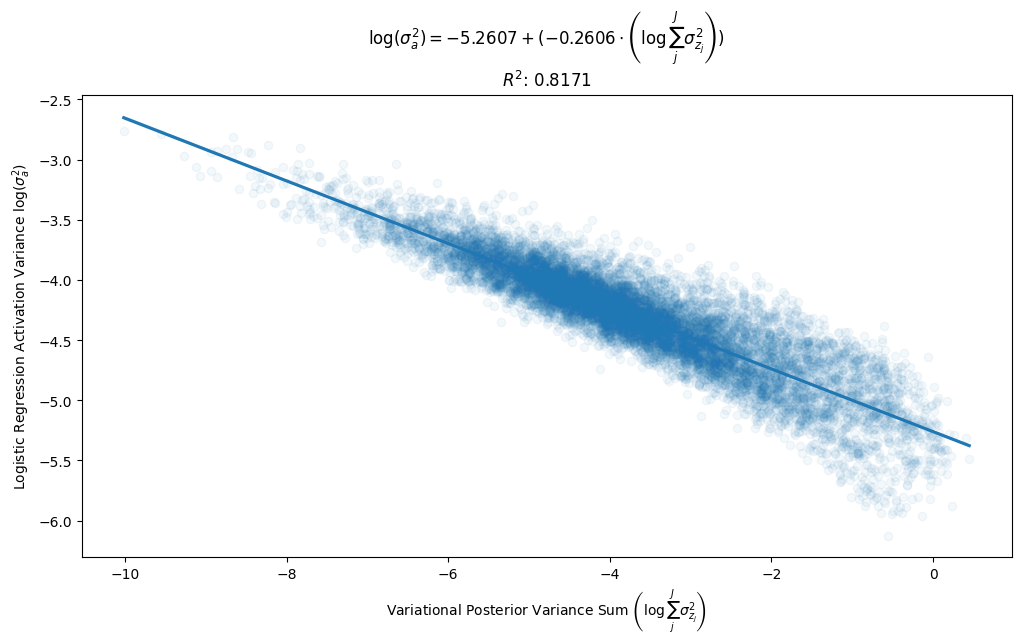

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))

p = 4

X, y = df[["z_log_var_sum"]], df["log_sigma_sq_a"]
reg = sklearn.linear_model.LinearRegression()
reg.fit(X, y)
title = (
    rf"$\log(\sigma^2_a) = {np.format_float_positional(reg.intercept_, precision=p)} +"
    rf"({np.format_float_positional(reg.coef_[0], precision=p)}\cdot \left(\log \sum_j^J \sigma^2_{{z_j}}\right))$"
    "\n"
    rf"$R^2$: {np.format_float_positional(reg.score(X, y), precision=p)}"
)
print(title)
ax.set_title(title)
sns.regplot(data=df, x="z_log_var_sum", y="log_sigma_sq_a", scatter_kws=dict(alpha=0.05), ax=ax)
ax.set_xlabel(r"Variational Posterior Variance Sum $\left(\log \sum_j^J \sigma^2_{z_j}\right)$")
ax.set_ylabel(r"Logistic Regression Activation Variance $\log(\sigma^2_a)$")
plt.show()

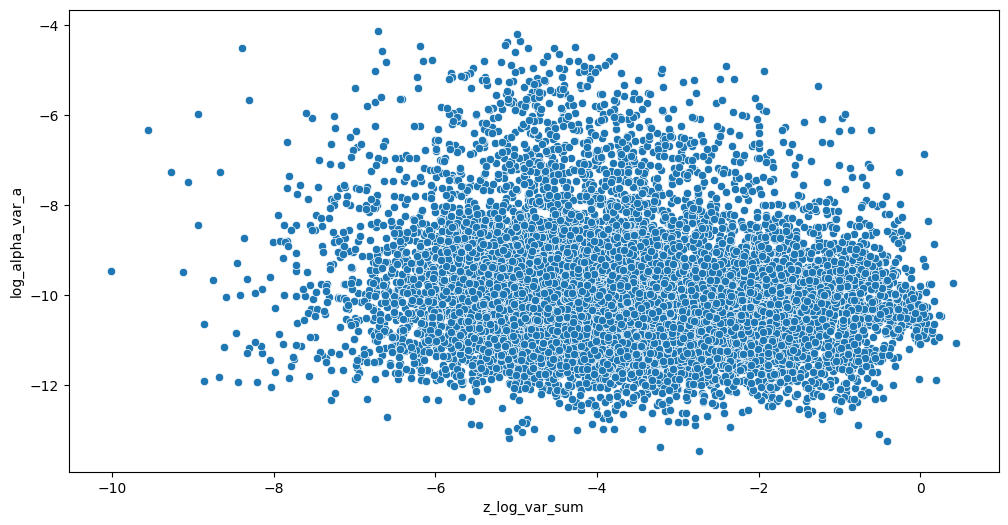

In [34]:
fig = plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="z_log_var_sum", y="log_alpha_var_a")
plt.show()

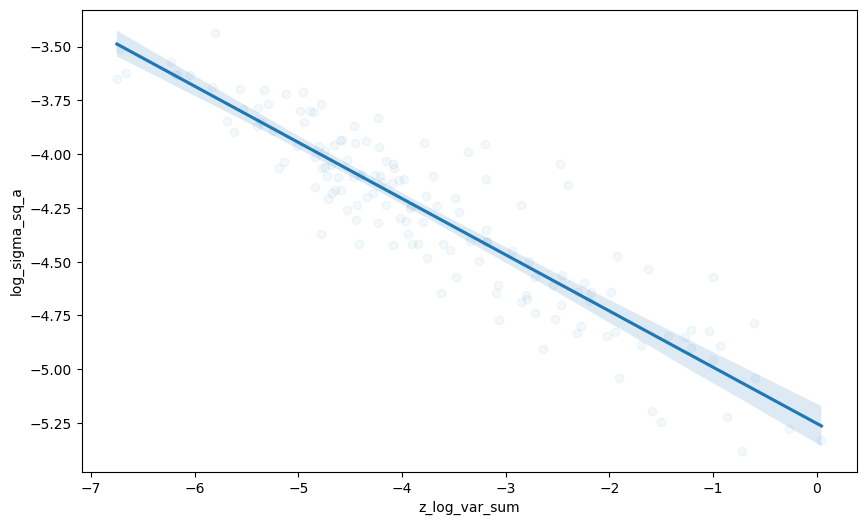

<Figure size 1200x600 with 0 Axes>

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
max_t_preds = species_preds.loc[species_preds.groupby("file_i")["attn_w"].idxmax()]
df_selected = z_sum_df.merge(max_t_preds,on=["file_i", "timestep"],how="inner")
df_selected["alpha_var_a"] = df_selected["sigma_sq_a"] * df["attn_w"]
df_selected["log_sigma_sq_a"] = np.log(df_selected["sigma_sq_a"])
df_selected["log_alpha_var_a"] = np.log(df_selected["alpha_var_a"])
fig = plt.figure(figsize=(12, 6))
sns.regplot(data=df_selected, x="z_log_var_sum", y="log_sigma_sq_a", scatter_kws=dict(alpha=0.05), ax=ax)
plt.show()

$\log(\sigma^2_a) = -5.2607 +(-0.2606\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8171


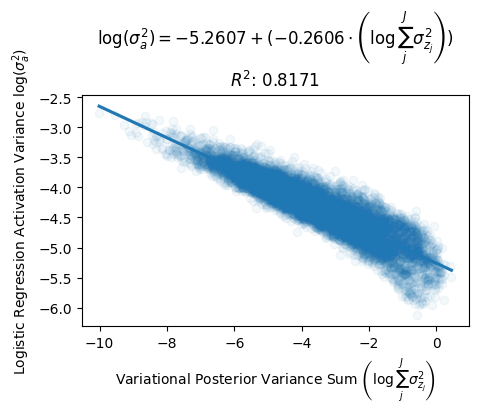

$\log(\sigma^2_a) = -3.4677 +(-0.2829\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8268


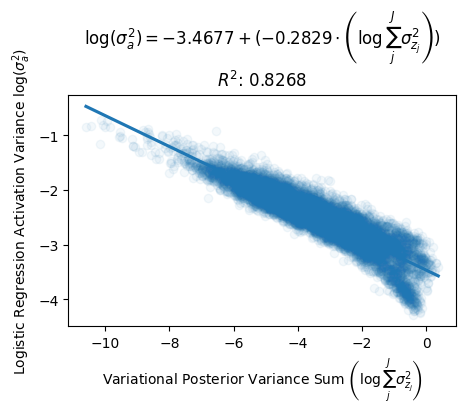

$\log(\sigma^2_a) = -3.8907 +(-0.2763\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8448


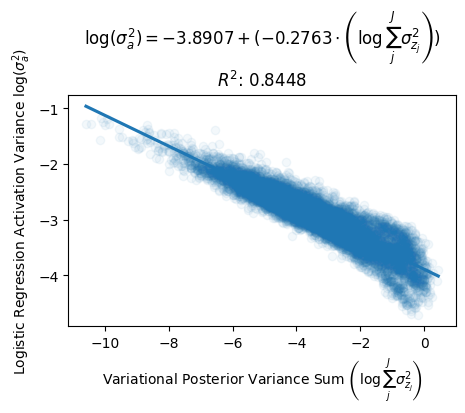

$\log(\sigma^2_a) = -3.7027 +(-0.2560\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8364


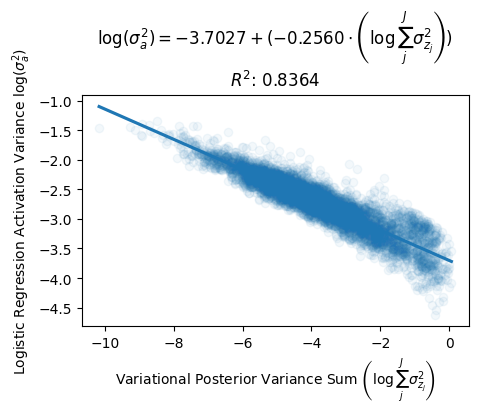

$\log(\sigma^2_a) = -4.1408 +(-0.3034\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8540


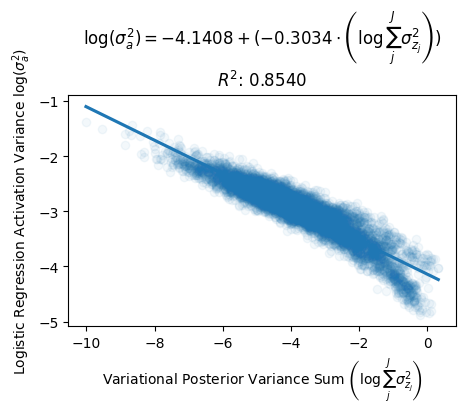

$\log(\sigma^2_a) = -4.0436 +(-0.279\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8557


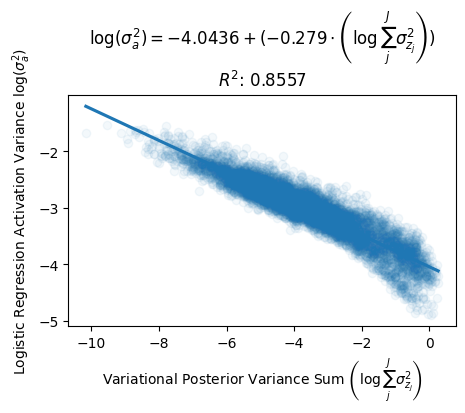

$\log(\sigma^2_a) = -4.9606 +(-0.3017\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8203


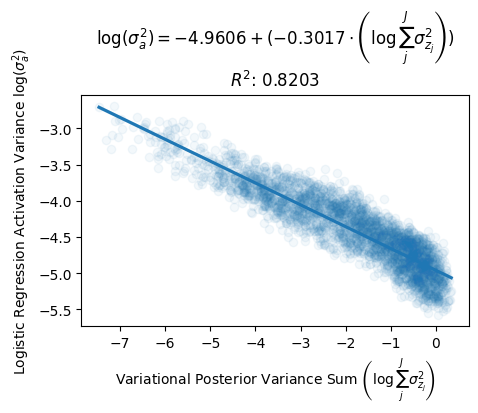

$\log(\sigma^2_a) = -4.9371 +(-0.2702\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8520


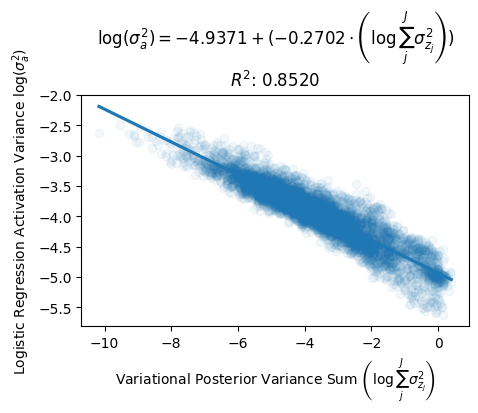

$\log(\sigma^2_a) = -3.1707 +(-0.2591\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.7951


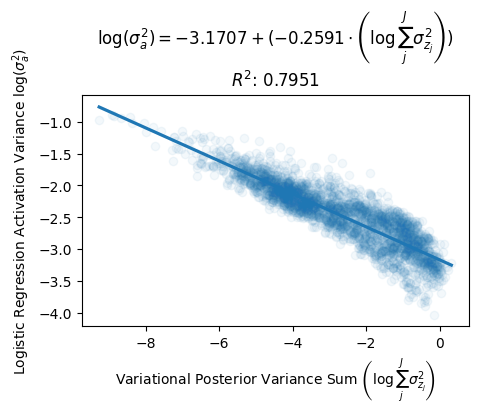

$\log(\sigma^2_a) = -3.0461 +(-0.251\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.6851


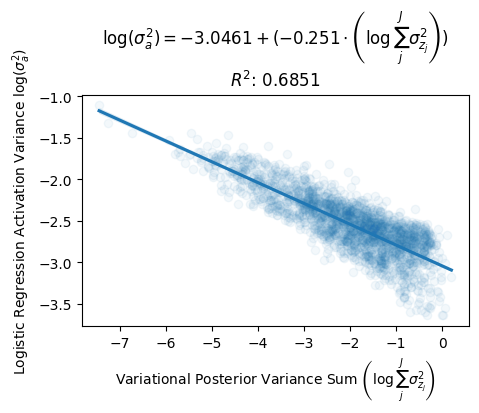

$\log(\sigma^2_a) = -4.2933 +(-0.2645\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8599


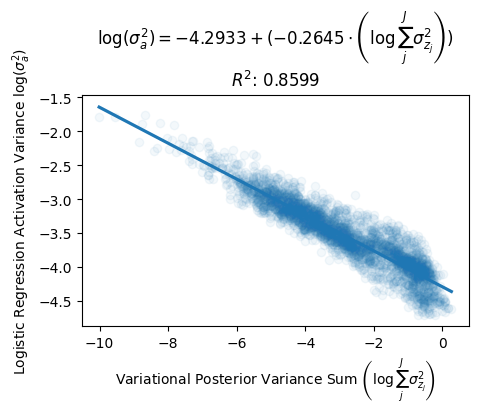

$\log(\sigma^2_a) = -5.1499 +(-0.2732\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.7869


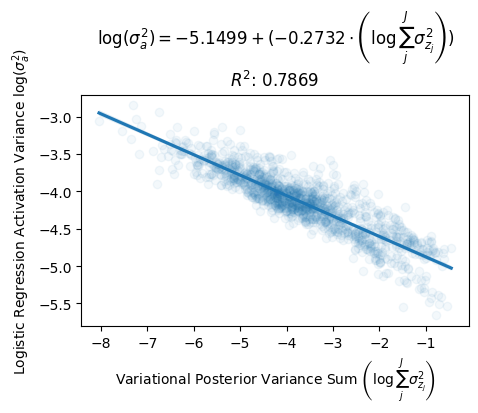

$\log(\sigma^2_a) = -4.4846 +(-0.3229\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8564


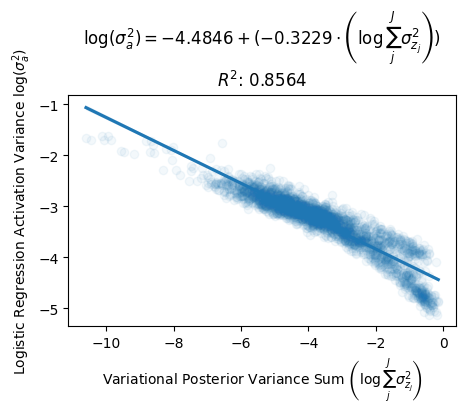

$\log(\sigma^2_a) = -3.0614 +(-0.2587\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8463


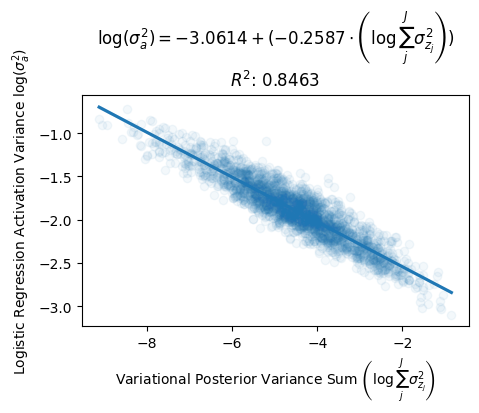

$\log(\sigma^2_a) = -3.4852 +(-0.2728\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8664


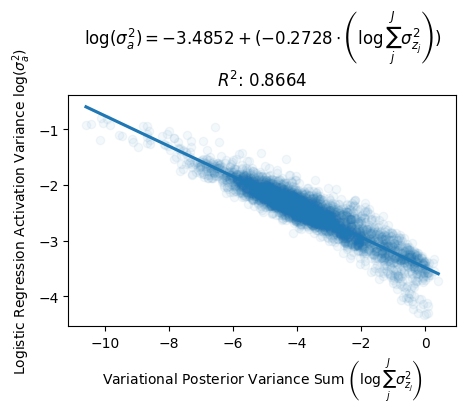

$\log(\sigma^2_a) = -3.2330 +(-0.2603\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.6481


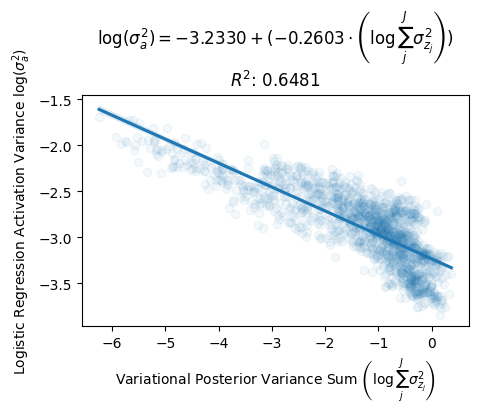

$\log(\sigma^2_a) = -3.9036 +(-0.2872\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8787


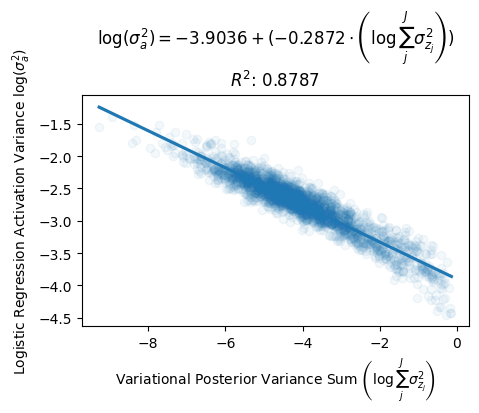

$\log(\sigma^2_a) = -3.4101 +(-0.2921\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.9603


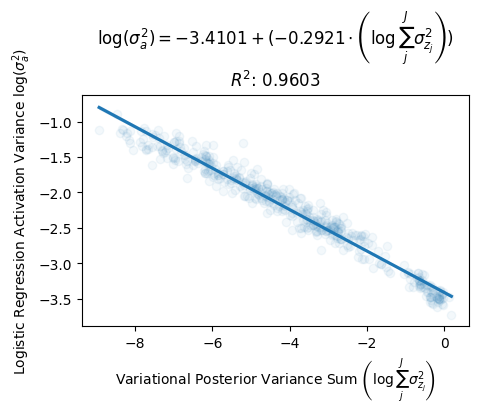

$\log(\sigma^2_a) = -3.8305 +(-0.2267\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.7557


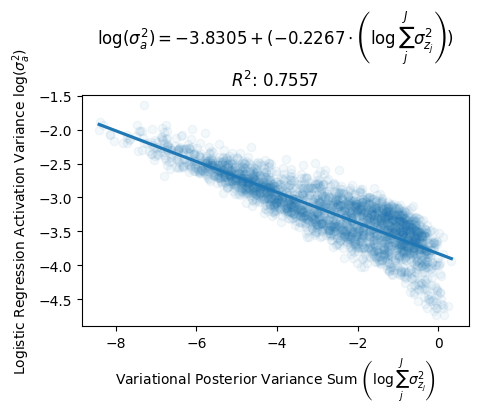

$\log(\sigma^2_a) = -3.2609 +(-0.2575\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8125


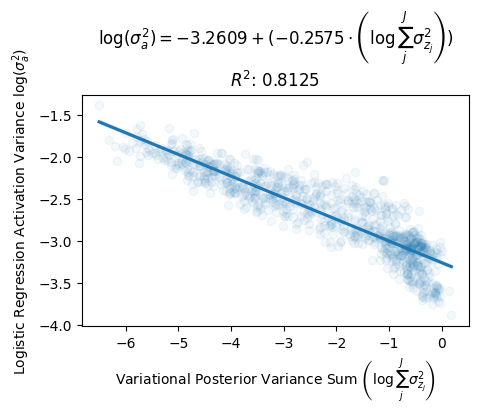

$\log(\sigma^2_a) = -3.2346 +(-0.2464\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8239


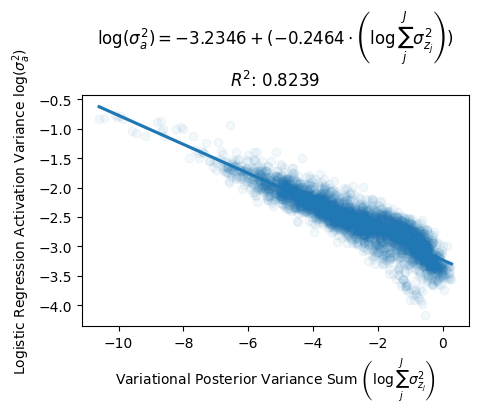

$\log(\sigma^2_a) = -2.9772 +(-0.2376\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.7461


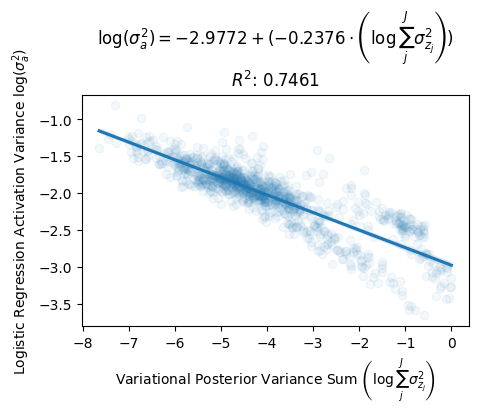

$\log(\sigma^2_a) = -3.3877 +(-0.2651\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8439


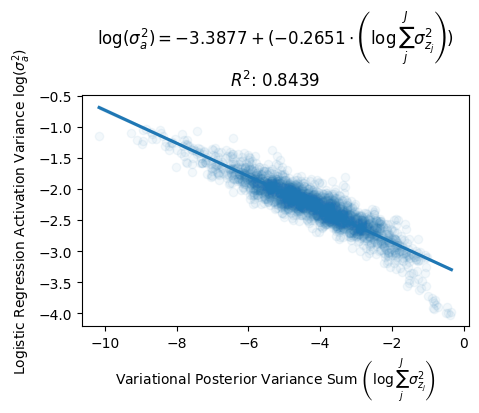

$\log(\sigma^2_a) = -3.669 +(-0.2683\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8706


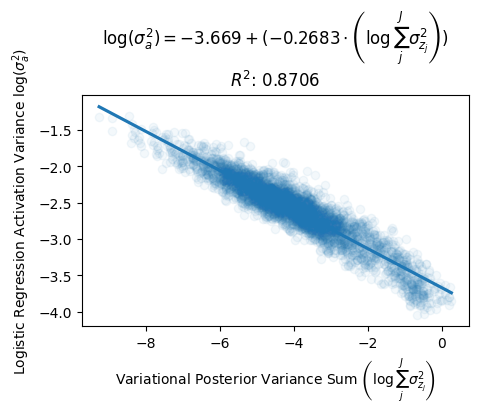

$\log(\sigma^2_a) = -3.4408 +(-0.2812\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.9479


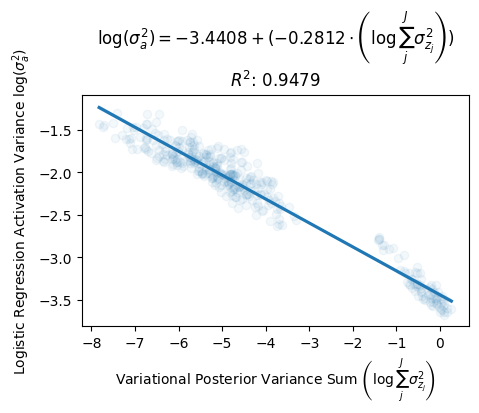

$\log(\sigma^2_a) = -3.1385 +(-0.2385\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8328


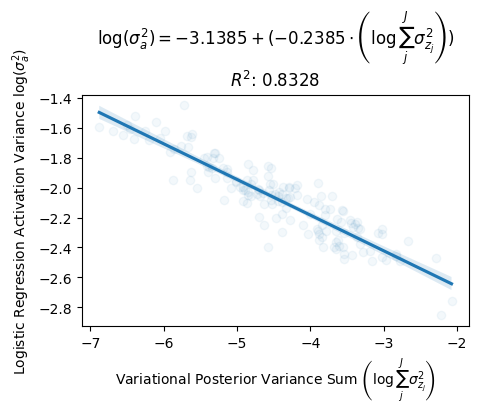

$\log(\sigma^2_a) = -2.8741 +(-0.2572\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.7943


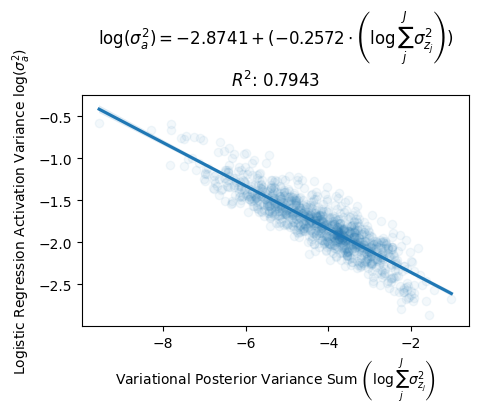

$\log(\sigma^2_a) = -4.1313 +(-0.2967\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8751


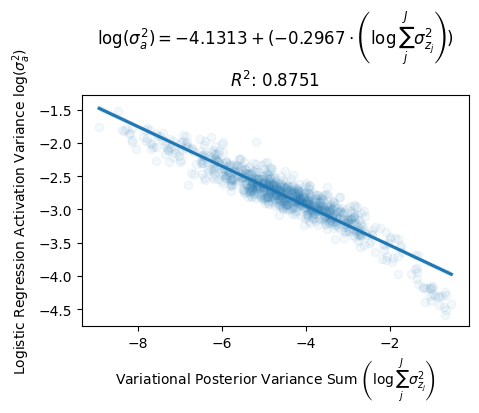

$\log(\sigma^2_a) = -3.9565 +(-0.2506\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.7379


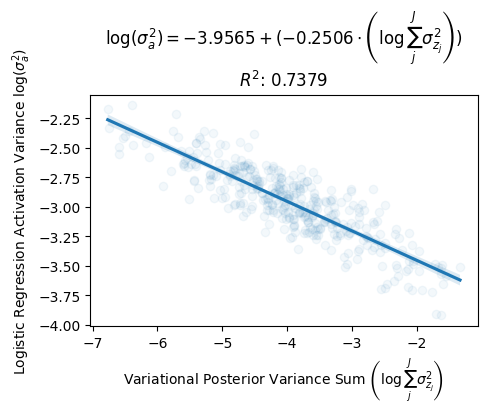

$\log(\sigma^2_a) = -3.1078 +(-0.2743\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8873


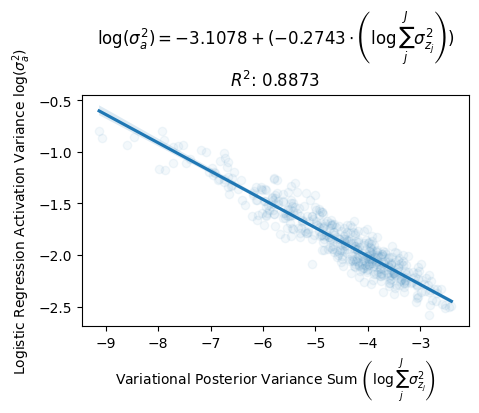

$\log(\sigma^2_a) = -2.9823 +(-0.2453\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8637


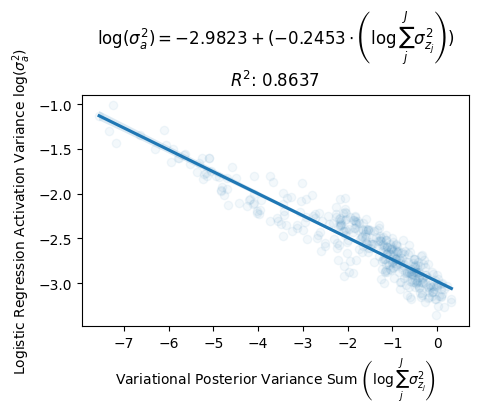

$\log(\sigma^2_a) = -3.7336 +(-0.2625\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8359


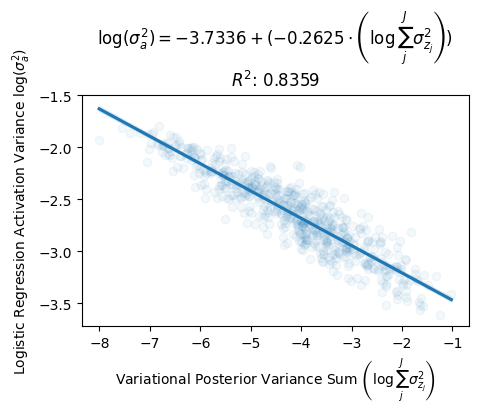

$\log(\sigma^2_a) = -3.4693 +(-0.2476\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8795


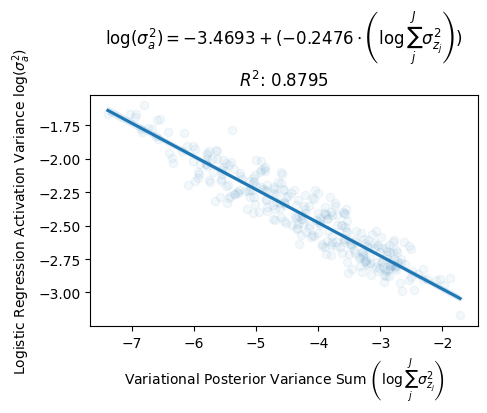

$\log(\sigma^2_a) = -5.0858 +(-0.3002\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.7659


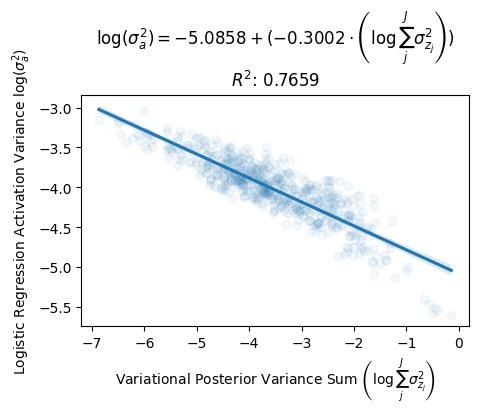

$\log(\sigma^2_a) = -3.7488 +(-0.2628\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8683


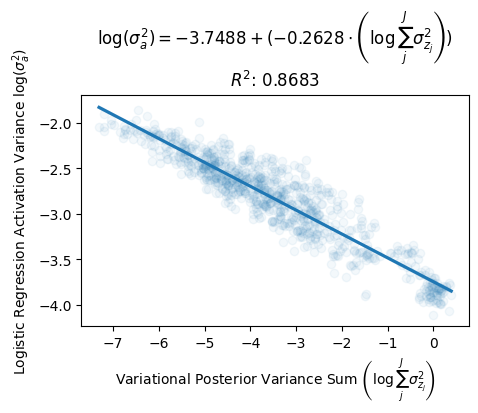

$\log(\sigma^2_a) = -4.0749 +(-0.2088\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.5204


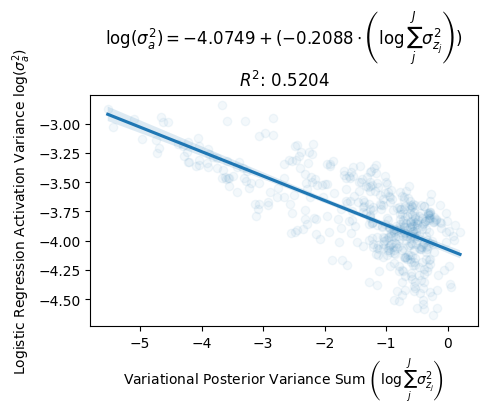

$\log(\sigma^2_a) = -4.2474 +(-0.2627\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8173


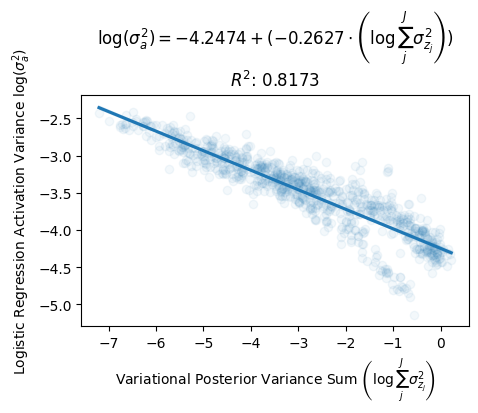

$\log(\sigma^2_a) = -4.4073 +(-0.3167\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.9477


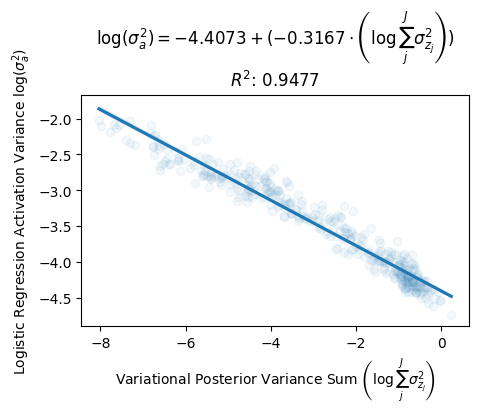

$\log(\sigma^2_a) = -3.3207 +(-0.2229\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.7640


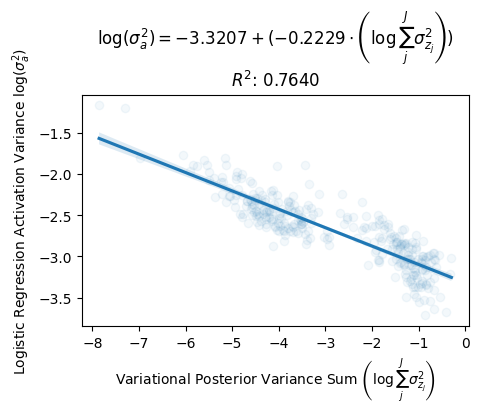

$\log(\sigma^2_a) = -3.7340 +(-0.2721\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.9534


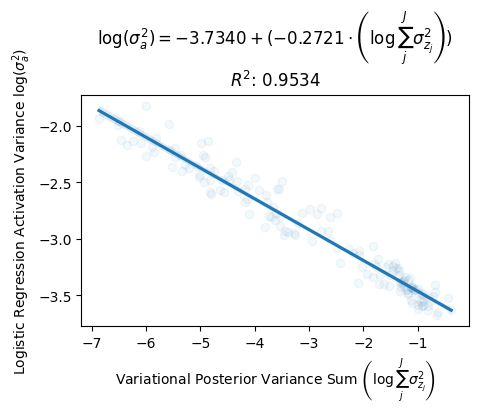

$\log(\sigma^2_a) = -5.6631 +(-0.3226\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.9258


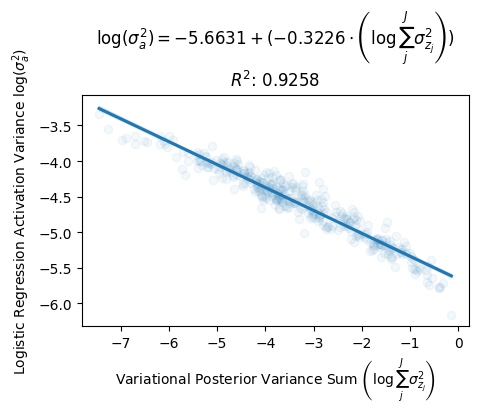

$\log(\sigma^2_a) = -5.1224 +(-0.2261\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.7881


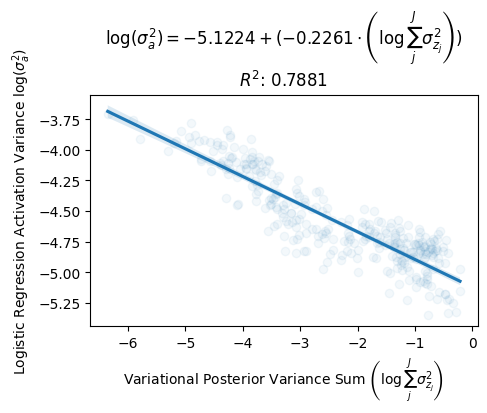

$\log(\sigma^2_a) = -3.3583 +(-0.3022\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.4082


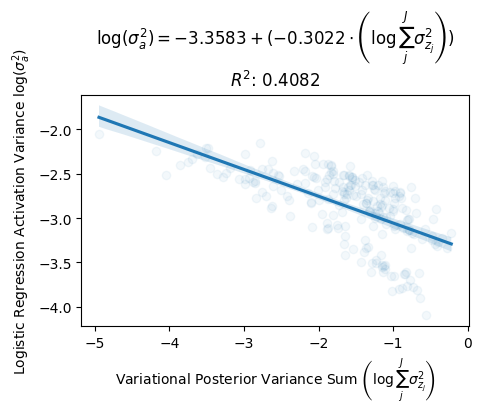

$\log(\sigma^2_a) = -3.5092 +(-0.3616\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.8799


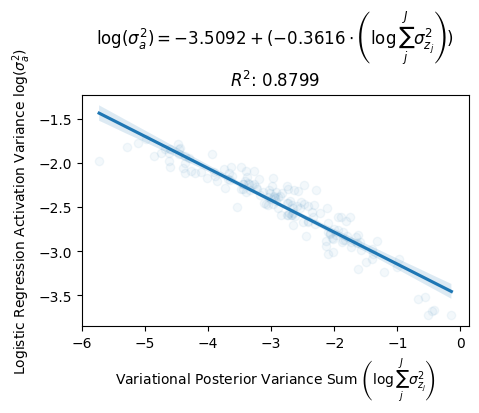

$\log(\sigma^2_a) = -3.743 +(-0.3785\cdot \left(\log \sum_j^J \sigma^2_{z_j}\right))$
$R^2$: 0.9370


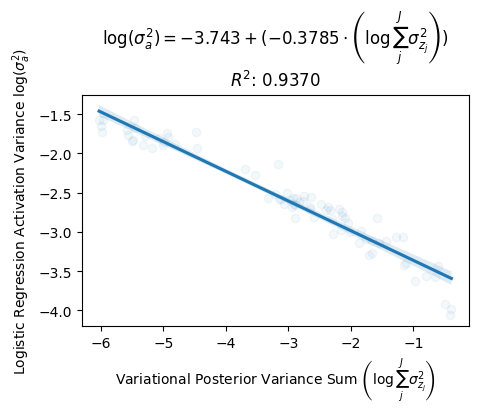

In [26]:
for species in order:
    species_labels = labels.loc[:, ["file_i", species]]
    present_species_idx = species_labels[species_labels[species] == 1].file_i
    species_features = features.loc[features.file_i.isin(present_species_idx), ["file_i", "timestep", *[f"z_log_var_{i}" for i in range(128)]]].copy()
    z_sum_df = np.exp(species_features.set_index(["file_i", "timestep"])).sum(axis=1).to_frame().rename(columns={0: "z_var_sum"}).reset_index()
    z_sum_df["z_log_var_sum"] = np.log(z_sum_df["z_var_sum"])
    preds = preds.rename(columns={"t": "timestep"})
    species_preds = preds[preds.species_i == clf.target_names.index(species)].sort_values(by=["file_i", "timestep", "sample_i"])
    species_preds = species_preds.groupby(["file_i", "timestep"])[["y_t_prob", "mu_a", "sigma_sq_a", "attn_w"]].mean().reset_index()
    species_preds = species_preds.loc[species_preds.file_i.isin(present_species_idx)]
    df = species_preds.merge(z_sum_df, on=["file_i", "timestep"])
    df["alpha_var_a"] = df["sigma_sq_a"] * df["attn_w"]
    df["log_sigma_sq_a"] = np.log(df["sigma_sq_a"])
    df["log_alpha_var_a"] = np.log(df["alpha_var_a"])
    fig, ax = plt.subplots(figsize=(5, 3))
    
    p = 4
    
    X, y = df[["z_log_var_sum"]], df["log_sigma_sq_a"]
    reg = sklearn.linear_model.LinearRegression()
    reg.fit(X, y)
    title = (
        rf"$\log(\sigma^2_a) = {np.format_float_positional(reg.intercept_, precision=p)} +"
        rf"({np.format_float_positional(reg.coef_[0], precision=p)}\cdot \left(\log \sum_j^J \sigma^2_{{z_j}}\right))$"
        "\n"
        rf"$R^2$: {np.format_float_positional(reg.score(X, y), precision=p)}"
    )
    print(title)
    ax.set_title(title)
    sns.regplot(data=df, x="z_log_var_sum", y="log_sigma_sq_a", scatter_kws=dict(alpha=0.05), ax=ax)
    ax.set_xlabel(r"Variational Posterior Variance Sum $\left(\log \sum_j^J \sigma^2_{z_j}\right)$")
    ax.set_ylabel(r"Logistic Regression Activation Variance $\log(\sigma^2_a)$")
    plt.show()
